In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt

In [2]:
data_dir = "/Users/ADMIN/desktop/pneumonia nn/chest_xray"
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')
normal_train = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_train = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))

/Users/ADMIN/desktop/pneumonia nn/chest_xray/train/NORMAL/NORMAL2-IM-0927-0001.jpeg
/Users/ADMIN/desktop/pneumonia nn/chest_xray/train/NORMAL/NORMAL2-IM-1056-0001.jpeg
/Users/ADMIN/desktop/pneumonia nn/chest_xray/train/NORMAL/IM-0427-0001.jpeg
/Users/ADMIN/desktop/pneumonia nn/chest_xray/train/PNEUMONIA/person63_bacteria_306.jpeg
/Users/ADMIN/desktop/pneumonia nn/chest_xray/train/PNEUMONIA/person1438_bacteria_3721.jpeg
/Users/ADMIN/desktop/pneumonia nn/chest_xray/train/PNEUMONIA/person755_bacteria_2659.jpeg


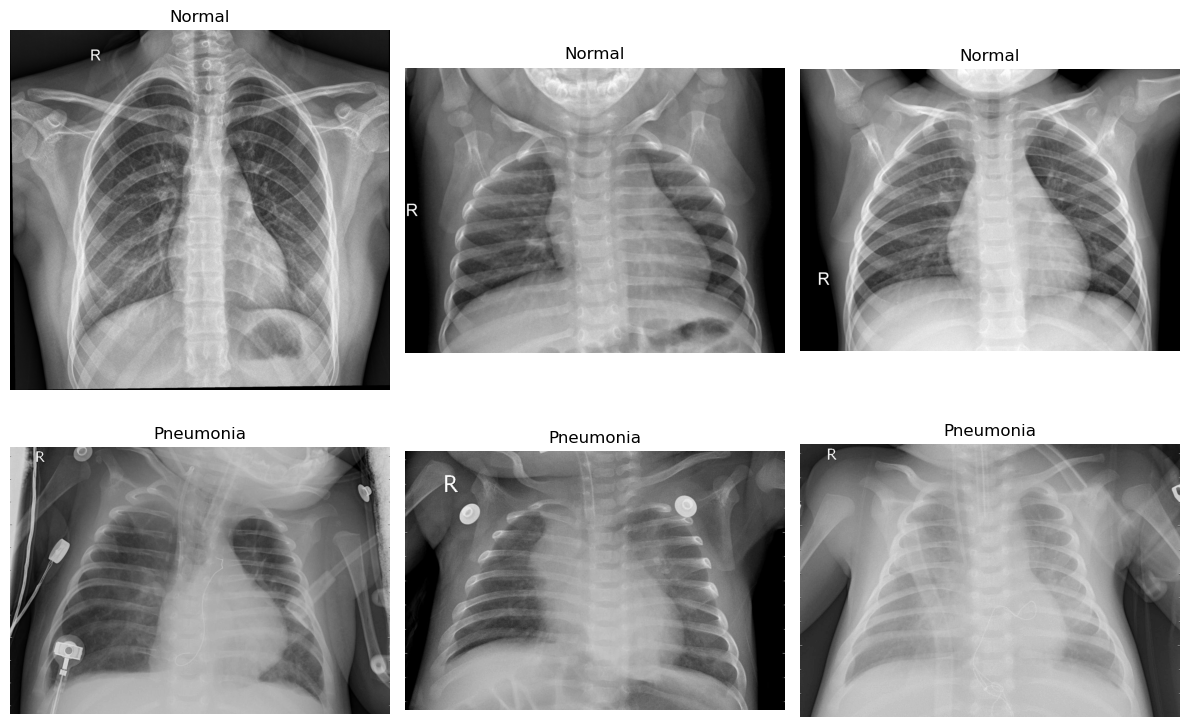

In [3]:
from PIL import Image
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i in range(3):
    img_path = os.path.join(train_dir, 'NORMAL', os.listdir(os.path.join(train_dir, 'NORMAL'))[i])
    img = Image.open(img_path)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')
    print (img_path)

for i in range(3):
    img_path = os.path.join(train_dir, 'PNEUMONIA', os.listdir(os.path.join(train_dir, 'PNEUMONIA'))[i])
    img = Image.open(img_path)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('Pneumonia')
    axes[1, i].axis('off')
    print (img_path)
plt.tight_layout()
plt.show()

In [4]:
#loading data
transform = transforms.Compose([transforms.Grayscale(),
                                transforms.Resize((64, 64)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
testset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(testset, batch_size=64
                                         ,shuffle = False, num_workers=0)
classes = [str(i) for i in range(10)]

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(2704,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,2)
    def forward(self,x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x,1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    

In [6]:
net = Net()
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

In [7]:
#training model
for epoch in range(4):
    running_loss = 0.0
    for i, data in enumerate(trainloader,0):
        inputs,labels = data
        optimizer.zero_grad()
        output = net(inputs)
        loss = criterion(output,labels)
        loss.backward()
        optimizer.step()
        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0
print("Finished training")

Finished training


In [8]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
#plt.imshow(torchvision.utils.make_grid(images))
#print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(10)))

In [9]:
#printing output from predictions
outputs = net(images)
_, predicted = torch.max(outputs, 1) # for best output
print('Predicted: ',' '.join(f'{classes[predicted[j]]:5s}'
                             for j in range(10)))

Predicted:  0     0     0     0     0     0     0     0     0     1    


In [10]:
total = 0
correct = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 95 %


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

net.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print("                 Predicted")
print("                NORMAL  PNEUMONIA")
print(f"Actual NORMAL      {cm[0][0]:4d}     {cm[0][1]:4d}")
print(f"Actual PNEUMONIA   {cm[1][0]:4d}     {cm[1][1]:4d}")

# Detailed metrics
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds, 
                          target_names=['NORMAL', 'PNEUMONIA']))

# Critical metrics
false_negatives = cm[1][0]  # Sick patients called healthy - DANGEROUS
false_positives = cm[0][1]  # Healthy patients called sick - less dangerous

print(f"\n⚠️  FALSE NEGATIVES (missed pneumonia): {false_negatives}")
print(f"    FALSE POSITIVES (false alarms): {false_positives}")

sensitivity = cm[1][1] / (cm[1][1] + cm[1][0]) * 100
specificity = cm[0][0] / (cm[0][0] + cm[0][1]) * 100

print(f"\nSensitivity (catch pneumonia): {sensitivity:.1f}%")
print(f"Specificity (identify healthy): {specificity:.1f}%")

Using device: cpu

Confusion Matrix:
                 Predicted
                NORMAL  PNEUMONIA
Actual NORMAL      1200      141
Actual PNEUMONIA     84     3791

Detailed Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.89      0.91      1341
   PNEUMONIA       0.96      0.98      0.97      3875

    accuracy                           0.96      5216
   macro avg       0.95      0.94      0.94      5216
weighted avg       0.96      0.96      0.96      5216


⚠️  FALSE NEGATIVES (missed pneumonia): 84
    FALSE POSITIVES (false alarms): 141

Sensitivity (catch pneumonia): 97.8%
Specificity (identify healthy): 89.5%


In [12]:
torch.save(net.state_dict(), 'pneumonia_model.pth')
print("Model saved!")

Model saved!
